**03 – Temporal Dynamics & Contextual Activity**

Move from static distributions to time-aware analysis:

- How blocking evolves over time
- Whether list-based blocking follows different temporal patterns
- How blocking relates to other activity (posts, likes, follows)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)

In [2]:
blocks = pd.read_parquet("blocks.parquet")
list_blocks = pd.read_parquet("list_blocks.parquet")
lists = pd.read_parquet("lists.parquet")
list_items = pd.read_parquet("list_items.parquet")


posts = pd.read_parquet("chunk_0_posts.parquet")
likes = pd.read_parquet("chunk_0_likes.parquet")
reposts = pd.read_parquet("chunk_0_reposts.parquet")
follows = pd.read_parquet("chunk_0_follow.parquet")

In [3]:
for df in [blocks, list_blocks, lists, list_items]:
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')


# activity tables already use created_at

Long-run blocking trends

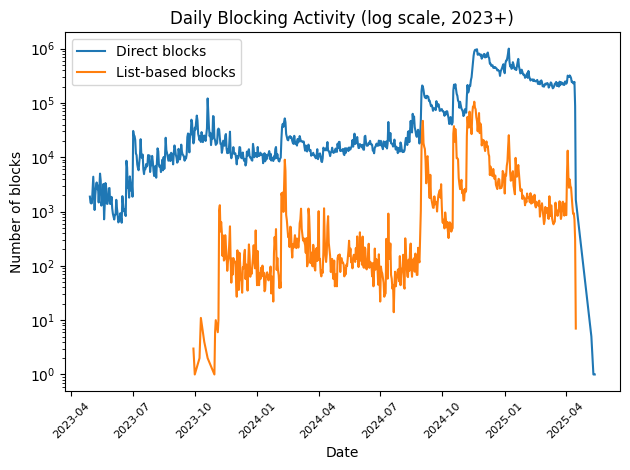

In [4]:
blocks_2023 = blocks[blocks['created_date'] >= '2023-01-01']
list_blocks_2023 = list_blocks[list_blocks['created_date'] >= '2023-01-01']

daily_direct = blocks_2023.groupby(blocks_2023['created_date'].dt.date).size()
daily_list = list_blocks_2023.groupby(list_blocks_2023['created_date'].dt.date).size()

plt.figure()
daily_direct.plot(logy=True, label='Direct blocks')
daily_list.plot(logy=True, label='List-based blocks')
plt.legend()
plt.title('Daily Blocking Activity (log scale, 2023+)')
plt.xlabel('Date')
plt.ylabel('Number of blocks')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

Block lists over time

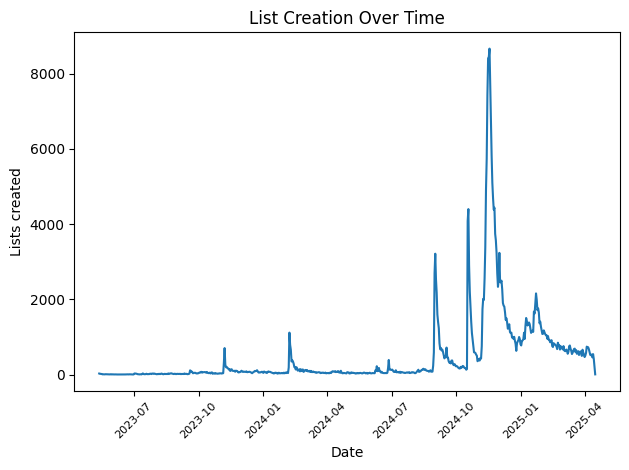

In [5]:
lists_2023 = lists[lists['created_date'] >= '2023-01-01']


daily_lists = lists_2023.groupby(lists_2023['created_date'].dt.date).size()

plt.figure()
daily_lists.plot()
plt.title('List Creation Over Time')
plt.xlabel('Date')
plt.ylabel('Lists created')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

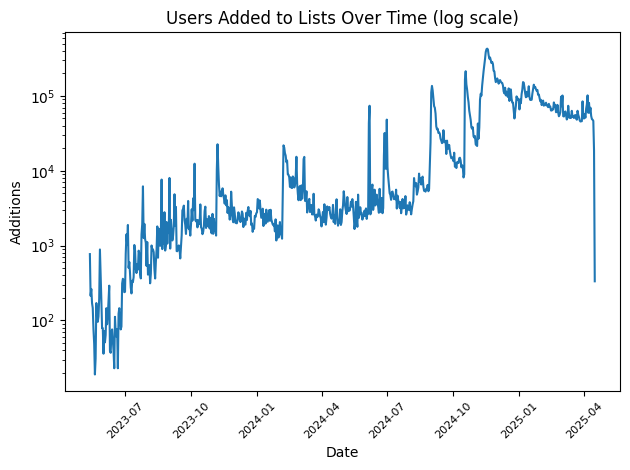

In [6]:
list_items_2023 = list_items[list_items['created_date'] >= '2023-01-01']


daily_list_items = list_items_2023.groupby(list_items_2023['created_date'].dt.date).size()

plt.figure()
daily_list_items.plot(logy=True)
plt.title('Users Added to Lists Over Time (log scale)')
plt.xlabel('Date')
plt.ylabel('Additions')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

How active are blockers?

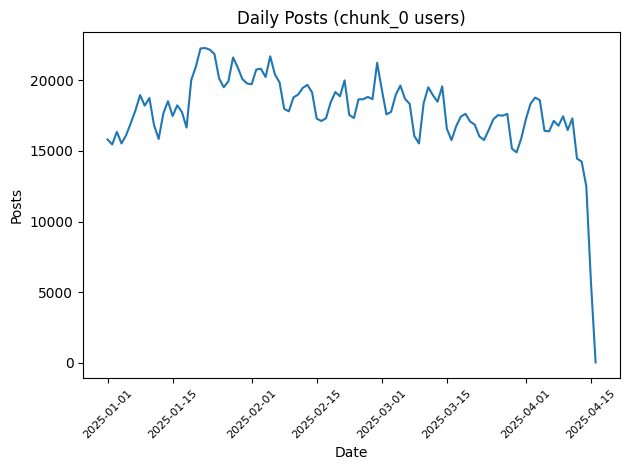

In [7]:
posts['date'] = posts['created_at'].dt.date
daily_posts = posts.groupby('date').size()

plt.figure()
daily_posts.plot()
plt.title('Daily Posts (chunk_0 users)')
plt.xlabel('Date')
plt.ylabel('Posts')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

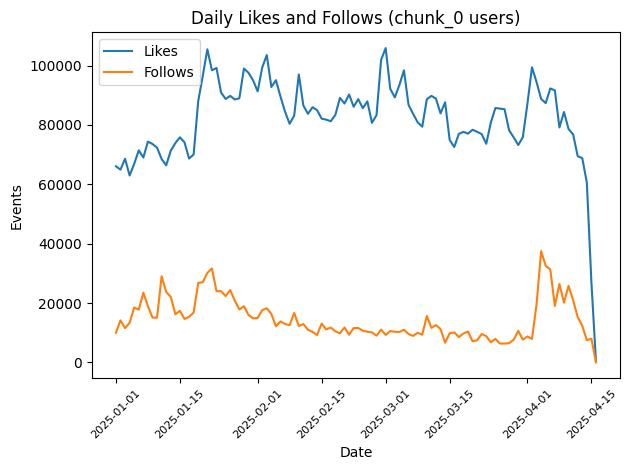

In [8]:
likes['date'] = likes['created_at'].dt.date
follows['date'] = follows['created_at'].dt.date


daily_likes = likes.groupby('date').size()
daily_follows = follows.groupby('date').size()

plt.figure()
daily_likes.plot(label='Likes')
daily_follows.plot(label='Follows')
plt.legend()
plt.title('Daily Likes and Follows (chunk_0 users)')
plt.xlabel('Date')
plt.ylabel('Events')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

Activity vs Blocking

<Figure size 640x480 with 0 Axes>

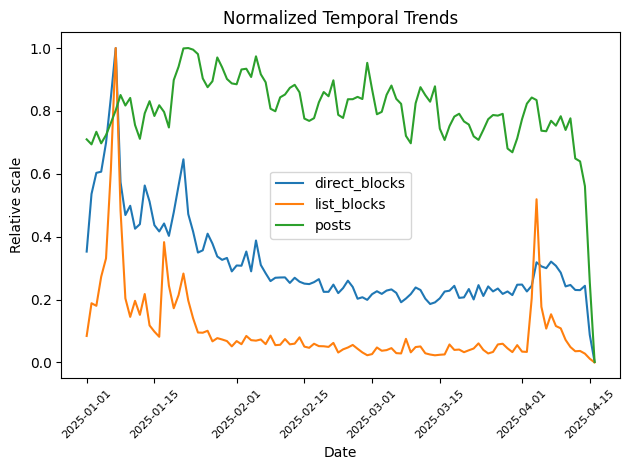

In [9]:
combined = pd.DataFrame({
'direct_blocks': daily_direct,
'list_blocks': daily_list,
'posts': daily_posts
}).dropna()


normalized = combined / combined.max()

plt.figure()
normalized.plot()
plt.title('Normalized Temporal Trends')
plt.xlabel('Date')
plt.ylabel('Relative scale')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()